In [1]:
# %pip install -e "../weac"
# 

In [1]:
%load_ext autoreload
%autoreload all

### Import of packages

In [1]:
import weac
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow
import ast


In [3]:
def try_parse_list(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except Exception:
            return x
    return x

def convert_object_columns(df):
    for col in df.columns[df.dtypes == object]:
        parsed = df[col].apply(try_parse_list)
        # keep only list-like entries for shape detection
        lists = parsed.apply(lambda v: v if isinstance(v, (list, tuple, np.ndarray)) else None)
        nonnull = lists.dropna()
        if nonnull.empty:
            # nothing to convert
            continue
        sample = nonnull.iloc[0]
        if all(isinstance(v, (int, float, np.integer, np.floating)) for v in sample):
            lengths = nonnull.apply(lambda v: len(v)).unique()
            if len(lengths) == 1:
                n = int(lengths[0])
                # fill None with nan-lists of correct length
                filled = lists.apply(lambda v: list(v) if v is not None else [np.nan] * n)
                cols = pd.DataFrame(filled.tolist(), index=df.index).astype(float)
                cols.columns = [f"{col}_{i}" for i in range(n)]
                df = df.drop(columns=[col]).join(cols)
            else:
                # variable-length lists: store numpy arrays (object dtype) but numeric inside
                df[col] = lists.apply(lambda v: np.array(v, dtype=float) if v is not None else np.array([], dtype=float))
        else:
            # sample not numeric lists -> leave column as-is
            continue
    return df

### Load experiment data

In [4]:
experiments = pd.read_parquet("M3DC_raw.parquet", engine="pyarrow")
experiments = convert_object_columns(experiments)
cols = ['Gc', 'G1c', 'G2c', 'G3c']
for c in cols:
    if c not in experiments.columns:
        experiments[c] = np.nan





### Compute load_vector_left from exp

In [5]:
def compute_load_vector(experiment):
    phi = experiment['phi']
    l_loading_head = 50 # mmm

    g = 9810 #mm/s^2
    mass_loading_head = 0.5404*1e-3 #t
    mass_snow = experiment['h_s'] * 290 * 50 * np.mean(experiment[['rho_1', 'rho_2','rho_3', 'rho_4']].values) *1e-12 # t/mm

    z_cog = np.sum(experiment[['rho_1', 'rho_2','rho_3', 'rho_4']].values * np.linspace(-3/8,3/8,4)*experiment['h_s'])/np.sum(experiment[['rho_1', 'rho_2','rho_3', 'rho_4']].values)


    W_x = -(g * (mass_loading_head + mass_snow) * np.sin(np.deg2rad(phi)))
    W_z = (g * (mass_loading_head + mass_snow) * np.cos(np.deg2rad(phi)))
    W_y = experiment['P_c_1'] # sign
    M_W_x = 0
    M_W_y = -mass_snow * g * np.sin(np.deg2rad(phi)) * z_cog - mass_snow * g * np.cos(np.deg2rad(phi)) * l_loading_head /2 - mass_loading_head * g *np.cos(np.deg2rad(phi)) * l_loading_head 
    M_W_z = experiment['P_c_1'] * l_loading_head# sign

    return np.array([W_x, W_y, W_z, M_W_x, M_W_y, M_W_z])


    


In [6]:
from weac.components import (
    Layer,
    Config,
    ScenarioConfig,
    ModelInput,
    WeakLayer,
    Segment,
)
import matplotlib.pyplot as plt
from weac.core.system_model import SystemModel, Slab
from weac.analysis.analyzer import Analyzer
from weac.analysis.plotter import Plotter

def setup_weac(experiment):
    layers = [Layer(rho = experiment['rho_1'], h = experiment['h_s']/4),
              Layer(rho = experiment['rho_2'], h = experiment['h_s']/4),
              Layer(rho = experiment['rho_3'], h = experiment['h_s']/4),
              Layer(rho = experiment['rho_4'], h = experiment['h_s']/4)]
    

    weak_layer = WeakLayer(rho = 125, h = 4.5, E=3.82,constitutive_model='PlaneStrain')

    if not np.isnan(experiment['weight number'] ) and experiment['phi'] >0: #von unten geschnitten mit gewichten am unteren ende

        l_lodading_head = 50 # mm
        l_dw = experiment['l_dw'] # mm
        
        l_load = experiment['weight number'] * 50 # mm
    
        a = experiment['a'] # mm
        l1 = l_dw-l_lodading_head
        l_total = experiment['L'] if not np.isnan(experiment['L']) else 10000 # mm
        if a < l_load + l_dw:
            l2 = a-l_dw
            l3 = l_load + l_dw - a
            l4 = l_total-(l_load + l_dw)
            if l1 >0:
                lengths = [l1, l2, l3, l4]
                is_bedded = [False, False, True, True]
                is_loaded = [False, True, True, False]
            elif l1 <= 0:
                lengths = [l2, l3, l4]
                is_bedded = [False, True, True]
                is_loaded = [True, True, False]
        elif a >= l_load + l_dw:
            l2 = l_load
            l3 = a - l_load - l_dw
            l4 = l_total - a
            if l1 >0:
                lengths = [l1, l2, l3, l4]
                is_bedded = [False, False, False, True]
                is_loaded = [False, True, False, False]
            elif l1 <= 0:
                lengths = [l2, l3, l4]
                is_bedded = [False, False, True]
                is_loaded = [True, False, False]


    elif experiment['phi'] <0 and not np.isnan(experiment['weight number'] ): # von oben geschnitten mit gewichten am unteren ende
        a = experiment['a'] # mm
        l_dw = experiment['l_dw'] # mm
        l_load = experiment['weight number'] * 50 # mm
        l_total = experiment['L'] if not np.isnan(experiment['L']) else 10000 # mm

        l1 = a
        l2 = l_total - a - l_dw-l_load
        l3 = l_load
        l4 = l_dw

        lengths = [l1,l2,l3,l4]
        is_bedded = [False, True, True, True]
        is_loaded = [False, False, True, False]
    elif np.isnan(experiment['weight number'] ): # keine Lasten. Schntt von oben oder unten
        a = experiment['a'] # mm
        l_total = experiment['L'] if not np.isnan(experiment['L']) else 10000 # mm
        lengths = [a, l_total - a]
        is_bedded = [False, True]
        is_loaded = [False, False]



    segments = [Segment(length = l, has_foundation = b, is_loaded = ld, m = 0)
                 for l,b,ld in zip(lengths, is_bedded, is_loaded)]

    if experiment['P_c_1']==0:
        print("Warning: zero point load applied")
        pass
    modeIII_scenario = ScenarioConfig(system_type = '-pst',
                                      phi = experiment['phi'], 
                                      theta = 0, 
                                      b=290,
                                      surface_load=experiment['total weights']*1e-3*9810/(experiment['weight number']*50*290) if not np.isnan(experiment['weight number'] ) else 0,
                                      load_vector_left=compute_load_vector(experiment),
                                      load_vector_right=np.array([0,0,0,0,0,0]),
                                      )
    config = Config(touchdown = False, 
                    backend = 'generalized')

    modelInput = ModelInput(layers=layers, 
                            weak_layer=weak_layer,
                            segments=segments, 
                            scenario_config=modeIII_scenario)

    system = SystemModel(model_input=modelInput,
                         config=config,)
    modeIII_analyzer = Analyzer(system_model=system)
    # xsl,zsl,xwl = modeIII_analyzer.rasterize_solution()
    # print(modeIII_analyzer.sm.scenario.system_type)
    # plt.plot(xsl,modeIII_analyzer.sm.fq.Vy(zsl, has_foundation=True))
    # modeIII_plotter = Plotter()
    # modeIII_plotter.plot_displacements(modeIII_analyzer, xsl,zsl)
    gdif = modeIII_analyzer.differential_ERR(unit = 'J/m^2')
    return gdif




In [7]:
gdif = []
for idx, experiment in experiments[experiments['P_e'] != 0].iterrows():
    err = setup_weac(experiment)
    experiments.loc[idx,['Gc','G1c','G2c','G3c']] = err
    gdif.append(err)

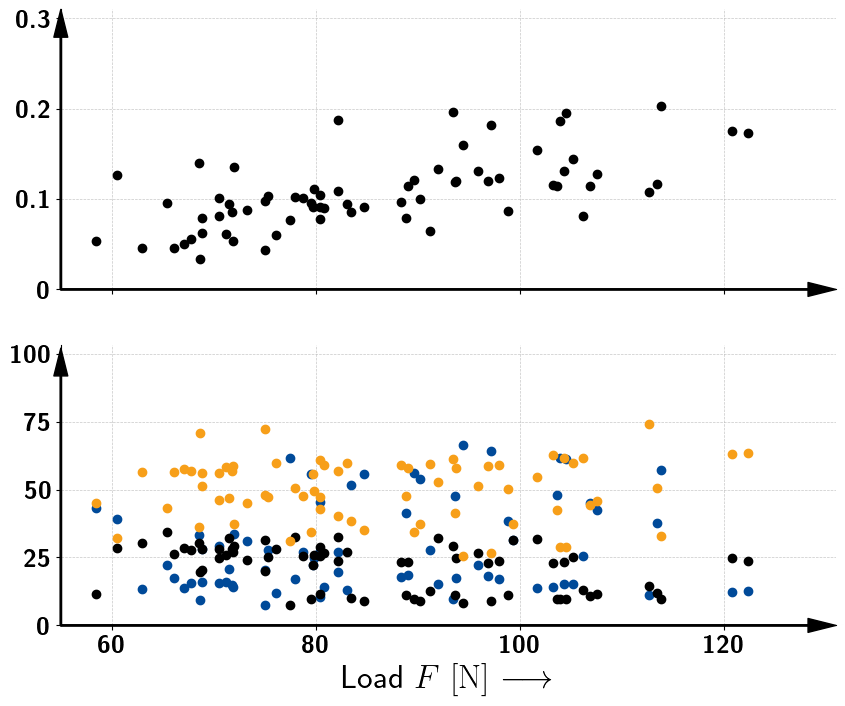

In [9]:
colors = ['#F79F19', '#004A99', '#000000']
fig, axs = plt.subplots(2,1,figsize = (10,8))
axs = axs.flatten()

axs[0].tick_params(labelsize=18, )
axs[1].tick_params(labelsize=18)
plt.rcParams['text.usetex'] = True


axs[0].tick_params(labelsize=18, )
axs[1].tick_params(labelsize=18)
plt.rcParams['text.usetex'] = True

axs[0].set_xlim([55,131])
axs[0].set_xticklabels([])

axs[0].set_ylim([0,0.31])
axs[0].set_yticks([0,0.1,0.2,0.3])
axs[0].set_yticklabels([r'\textbf{0}', r'\textbf{0.1}', r'\textbf{0.2}', r'\textbf{0.3}'])
axs[0].set_xticks([60,80,100,120])
axs[0].set_xticklabels(['','', '',''])
axs[0].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

axs[1].set_ylim([0,103])
axs[1].set_yticks([0,25,50,75,100])
axs[1].set_yticklabels([r'\textbf{0}', r'\textbf{25}', r'\textbf{50}', r'\textbf{75}', r'\textbf{100}'])

axs[1].set_xlim([55,131])
axs[1].set_xticks([60,80,100,120])
axs[1].set_xticklabels([r'\textbf{60}', r'\textbf{80}', r'\textbf{100}', r'\textbf{120}'])
axs[1].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)


axs[1].set_xlabel(r'Load $F$ $[\mathrm{N}]$ $\longrightarrow$',fontsize=24, fontdict={'family':'sans-serif'})


axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].annotate('', xy=(131, 0), xytext=(55, 0),
            arrowprops=dict( width = 1., headlength = 20., headwidth = 10. , color = 'black'))  # X-axis arrow
axs[0].annotate('', xy=(55, 0.31), xytext=(55, 0),
           arrowprops=dict( width = 1., headlength = 20., headwidth = 10., color = 'black' ))  # Y-axis arrow


axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].annotate('', xy=(131, 0), xytext=(55, 0),
            arrowprops=dict( width = 1., headlength = 20., headwidth =  10.,
                            color ='black'))
axs[1].annotate('', xy=(55, 102), xytext=(55, 0),
           arrowprops=dict( width = 1., headlength = 20., headwidth = 10., color = 'black' ))  # Y-axis arrow

axs[0].plot(np.array(experiments['P_c_1']), np.array(experiments['Gc']), 'ok')

axs[1].plot(np.array(experiments['P_c_1']), np.array(experiments['G1c'])/np.array(experiments['Gc'])*100, 'o', c=colors[1], label=r'\textbf{Mode I contribution}')
axs[1].plot(np.array(experiments['P_c_1']), np.array(experiments['G2c'])/np.array(experiments['Gc'])*100, 'o', c=colors[2], label=r'\textbf{Mode II contribution}')
axs[1].plot(np.array(experiments['P_c_1']), np.array(experiments['G3c'])/np.array(experiments['Gc'])*100, 'o', c=colors[0], label=r'\textbf{Mode III contribution}')



In [8]:
psts = experiments[experiments['P_e'] == 0]
for idx, pst in psts.iterrows():
    layers = [Layer(rho = pst['rho_1'], h = pst['h_s']/4),
              Layer(rho = pst['rho_2'], h = pst['h_s']/4),
              Layer(rho = pst['rho_3'], h = pst['h_s']/4),
              Layer(rho = pst['rho_4'], h = pst['h_s']/4)]
    weak_layer = WeakLayer(rho = 125, h = 4.5, E=1)
    pstscenario =ScenarioConfig(system_type='-pst',
                                      phi = pst['phi'], 
                                      theta = 0, 
                                      surface_load=pst['total weights']*1e-3*9810/(pst['weight number']*50*290) if not np.isnan(pst['weight number'] ) else 0,
                                      )
    
    a = pst['a'] # mm
    l_load = pst['weight number'] * 50 # mm
    l_dw = pst['l_dw'] # mm
    l_total = pst['L'] # mm
    if a < l_load + l_dw:
        pst_segements = [Segment(length= l_dw, 
                                 has_foundation=False, 
                                 is_loaded=False, m=0),
                        Segment(length= a - l_dw, 
                                has_foundation=False, 
                                is_loaded=True, m=0),
                        Segment(length= l_load + l_dw - a, 
                                has_foundation=True, 
                                is_loaded=True, m=0),
                        Segment(length= l_total - (l_load + l_dw), 
                                has_foundation=True, 
                                is_loaded=False, m=0)]
    elif a >= l_load + l_dw:
        pst_segements = [Segment(length= l_dw, 
                                 has_foundation=False, 
                                 is_loaded=False, m=0),
                        Segment(length= l_load, 
                                has_foundation=False, 
                                is_loaded=True, m=0),
                        Segment(length= a - l_load - l_dw, 
                                has_foundation=False, 
                                is_loaded=False, m=0),
                        Segment(length= l_total - a, 
                                has_foundation=True, 
                                is_loaded=False, m=0)]
    
    pst_config = Config(touchdown = False, 
                    backend = 'classic')
    
    pst_modelInput = ModelInput(layers=layers, 
                            weak_layer=weak_layer,
                            segments=pst_segements, 
                            scenario_config=pstscenario)   
    pst_system = SystemModel(model_input=pst_modelInput,
                         config=pst_config,)
    pst_analyzer = Analyzer(system_model=pst_system)
    pst_err = pst_analyzer.differential_ERR(unit = 'J/m^2')
    psts.loc[idx,'Gc'] = pst_err[0]
    psts.loc[idx,'G1c'] = pst_err[1]
    psts.loc[idx,'G2c'] = pst_err[2]
    psts.loc[idx,'G3c'] = pst_err[3]

print(psts[['AFN','Gc','G1c','G2c','G3c']])


    AFN        Gc       G1c       G2c  G3c
47    1  0.316883  0.315975  0.000908  0.0
48    2  0.432906  0.427779  0.005127  0.0
49    3  0.286044  0.283656  0.002389  0.0
50    4  0.298531  0.296491  0.002040  0.0
51    5  0.346606  0.341546  0.005061  0.0
52    6  0.274405  0.273454  0.000951  0.0
53    7  0.305534  0.304472  0.001061  0.0


In [9]:
psts = experiments[experiments['P_e'] == 0]
for idx, pst in psts.iterrows():
    layers = [Layer(rho = pst['rho_1'], h = pst['h_s']/4),
              Layer(rho = pst['rho_2'], h = pst['h_s']/4),
              Layer(rho = pst['rho_3'], h = pst['h_s']/4),
              Layer(rho = pst['rho_4'], h = pst['h_s']/4)]
    weak_layer = WeakLayer(rho = 125, h = 4.5, E=1,constitutive_model='Uniaxial')
    pstscenario =ScenarioConfig(system_type='-pst',
                                      phi = pst['phi'], 
                                      theta = 0, 
                                      surface_load=pst['total weights']*1e-3*9810/(pst['weight number']*50*290) if not np.isnan(pst['weight number'] ) else 0,
                                      )
    
    a = pst['a'] # mm
    l_load = pst['weight number'] * 50 # mm
    l_dw = pst['l_dw'] # mm
    l_total = pst['L'] # mm
    if a < l_load + l_dw:
        pst_segements = [Segment(length= l_dw, 
                                 has_foundation=False, 
                                 is_loaded=False, m=0),
                        Segment(length= a - l_dw, 
                                has_foundation=False, 
                                is_loaded=True, m=0),
                        Segment(length= l_load + l_dw - a, 
                                has_foundation=True, 
                                is_loaded=True, m=0),
                        Segment(length= l_total - (l_load + l_dw), 
                                has_foundation=True, 
                                is_loaded=False, m=0)]
    elif a >= l_load + l_dw:
        pst_segements = [Segment(length= l_dw, 
                                 has_foundation=False, 
                                 is_loaded=False, m=0),
                        Segment(length= l_load, 
                                has_foundation=False, 
                                is_loaded=True, m=0),
                        Segment(length= a - l_load - l_dw, 
                                has_foundation=False, 
                                is_loaded=False, m=0),
                        Segment(length= l_total - a, 
                                has_foundation=True, 
                                is_loaded=False, m=0)]
    
    pst_config = Config(touchdown = False, 
                    backend = 'generalized',
                    b = 290)
    
    pst_modelInput = ModelInput(layers=layers, 
                            weak_layer=weak_layer,
                            segments=pst_segements, 
                            scenario_config=pstscenario)   
    pst_system = SystemModel(model_input=pst_modelInput,
                         config=pst_config,)
    pst_analyzer = Analyzer(system_model=pst_system)

    
    pst_err = pst_analyzer.differential_ERR(unit = 'J/m^2')
    psts.loc[idx,'Gc'] = pst_err[0]
    psts.loc[idx,'G1c'] = pst_err[1]
    psts.loc[idx,'G2c'] = pst_err[2]
    psts.loc[idx,'G3c'] = pst_err[3]

print(psts[['AFN','Gc','G1c','G2c','G3c']])


    AFN        Gc       G1c       G2c           G3c
47    1  0.320171  0.318467  0.001704  3.250122e-30
48    2  0.435577  0.427741  0.007836  8.607234e-32
49    3  0.290674  0.286603  0.004071  1.176741e-32
50    4  0.301341  0.297877  0.003463  9.027360e-33
51    5  0.344075  0.336836  0.007238  5.915233e-32
52    6  0.280001  0.278019  0.001983  9.632615e-32
53    7  0.313898  0.311565  0.002333  5.075883e-32


Text(0, 0.5, 'Giiic')

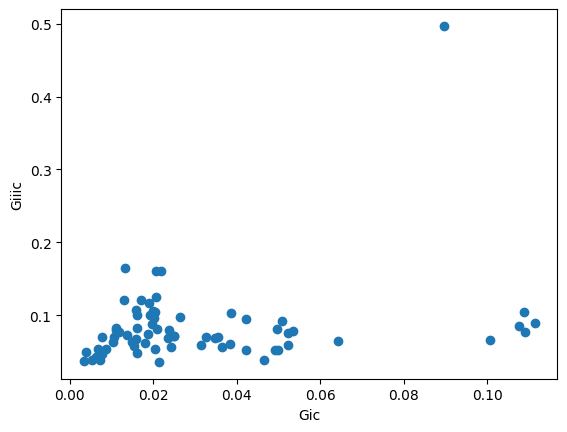

In [22]:
plt.scatter(x=experiments['G1c'],y=experiments['G3c'])
plt.xlabel('Gic')
plt.ylabel('Giiic')


Text(0, 0.5, 'Giiic')

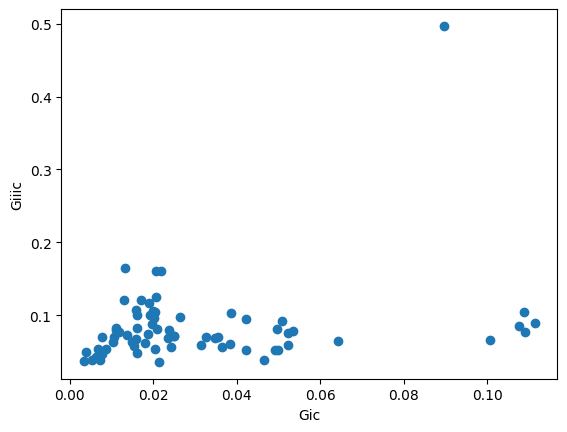

In [15]:
plt.scatter(x=experiments['G1c'],y=experiments['G3c'])
plt.xlabel('Gic')
plt.ylabel('Giiic')


(0.0, 100.0)

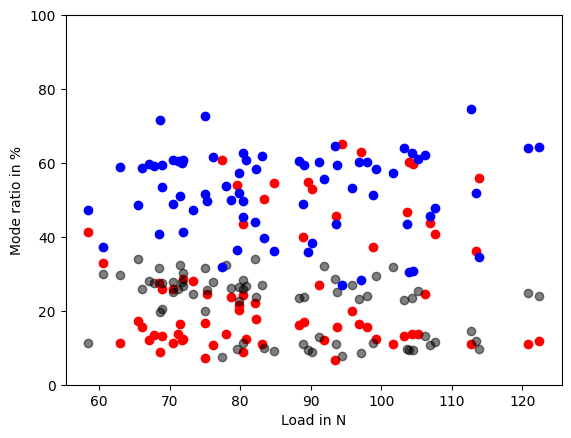

In [63]:
fig, axs = plt.subplots(1, 1)

axs.scatter(experiments['P_c_1'],experiments['G1c']/experiments['Gc']*100, c = 'r')
axs.scatter(experiments['P_c_1'],experiments['G2c']/experiments['Gc']*100, c = 'k',alpha=0.5)
axs.scatter(experiments['P_c_1'],experiments['G3c']/experiments['Gc']*100, c = 'b')
axs.set_xlabel('Load in N')
axs.set_ylabel('Mode ratio in %')

axs.set_ylim(0,100)

(-2.0, 102.0)

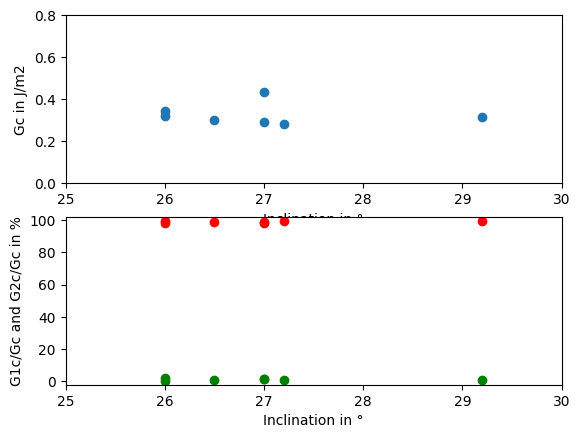

In [58]:
fig,axs = plt.subplots(2,1)
axs.flatten()

axs[0].set_ylim(0,0.8)

axs[0].scatter(psts['phi'],psts['Gc'])

axs[0].set_xlabel('Inclination in °')
axs[0].set_ylabel('Gc in J/m2')

axs[0].set_xlim(25,30)

axs[1].scatter(psts['phi'],psts['G1c']/psts['Gc']*100,c = 'r')
axs[1].scatter(psts['phi'],psts['G2c']/psts['Gc']*100,c = 'g')

axs[1].set_xlabel('Inclination in °')
axs[1].set_ylabel('G1c/Gc and G2c/Gc in %')
axs[1].set_xlim(25,30)
axs[1].set_ylim(-2,102)

<Axes: xlabel='P_c_1', ylabel='Gc'>

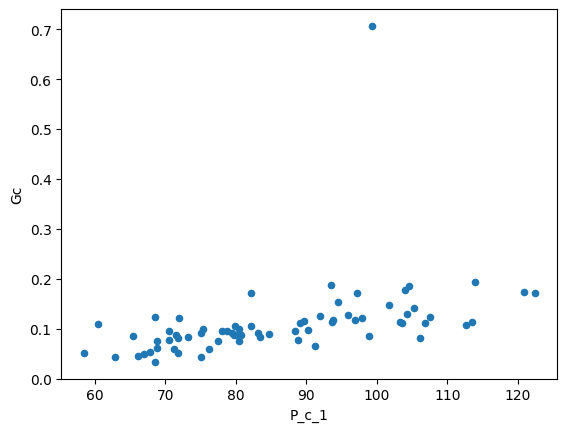

In [24]:
experiments.plot.scatter(y='Gc',x = 'P_c_1')

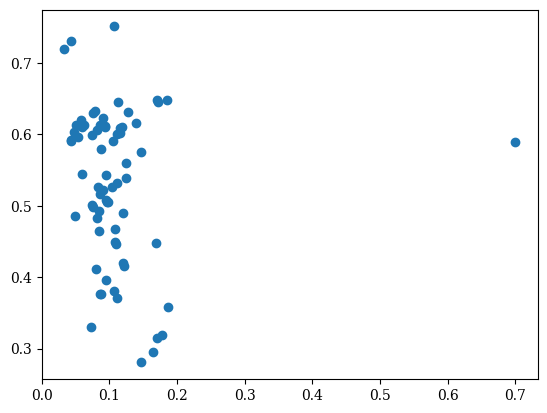

In [77]:
plt.scatter(x= experiments['Gc'],y = experiments['G3c']/experiments['Gc'])

In [67]:
print(experiments[['AFN','P_c_1','Gc']])

    AFN     P_c_1        Gc
0   176  112.6717  0.106886
1   177  104.2996  0.127576
2   178  103.2569  0.113233
3   180  105.2196  0.140177
4   181   93.7193  0.115871
..  ...       ...       ...
72  276   75.0123  0.043662
73  277   67.7748  0.053123
74  279   67.0388  0.048351
75  280   76.1470  0.058581
76  281   68.6028  0.033230

[77 rows x 3 columns]


In [49]:
gdif

[array([0.10688608, 0.01103654, 0.0155706 , 0.08027894]),
 array([0.12757609, 0.01671392, 0.03026674, 0.08059543]),
 array([0.11323303, 0.01398714, 0.02620542, 0.07304047]),
 array([0.14017663, 0.01815177, 0.03564008, 0.08638479]),
 array([0.11587119, 0.01699737, 0.02920018, 0.06967364]),
 array([0.0934139 , 0.01432146, 0.02205416, 0.05703828]),
 array([0.11943991, 0.01765547, 0.02893487, 0.07284957]),
 array([0.17002529, 0.01886883, 0.04093568, 0.11022078]),
 array([0.17169085, 0.01789039, 0.04289535, 0.11090511]),
 array([0.10430728, 0.02150717, 0.02785133, 0.05494878]),
 array([0.11641733, 0.01808245, 0.02740004, 0.07093484]),
 array([0.08720911, 0.01673975, 0.01989877, 0.0505706 ]),
 array([0.09694374, 0.02263403, 0.02526817, 0.04904154]),
 array([0.10486506, 0.01764736, 0.02525348, 0.06196422]),
 array([0.11072485, 0.01790503, 0.02639595, 0.06642387]),
 array([0.08682329, 0.01023219, 0.02332287, 0.05326823]),
 array([0.07390266, 0.00913553, 0.02052396, 0.04424317]),
 array([0.0812

In [19]:
compute_load_vector(experiments.iloc[0])

0.0005404 0.000460955


array([-4.22903645e+00,  1.12671700e+02,  8.86635930e+00,  0.00000000e+00,
       -3.44152707e+02,  5.63358500e+03])

In [28]:

np.sum(experiments[['rho_4', 'rho_4','rho_1', 'rho_1']].iloc[0].values* np.linspace(-3/8,3/8,4)*experiments['h_s'].iloc[0])/np.sum(experiments[['rho_1', 'rho_1','rho_4', 'rho_4']].iloc[0].values)

np.float64(-1.9576271186440677)

In [6]:
experiments[['P_c_0', 'P_c_1']].iloc[0].values

array([ 12.6756, 112.6717])

In [29]:
np.linspace(-3/8,3/8,4)*experiments['h_s'].iloc[0]

array([-41.25, -13.75,  13.75,  41.25])

In [32]:
experiments[['rho_1', 'rho_2','rho_3', 'rho_4']].iloc[0].values*np.linspace(-3/8,3/8,4)*experiments['h_s'].iloc[0]

array([-11302.5,  -3905. ,   3877.5,  13035. ])

In [13]:
for idx, exp in experiments.iterrows():
    print(exp['P_c_1'])    

112.6717
104.2996
103.2569
105.2196
93.7193
88.3832
97.9514
122.3933
120.8292
79.827
96.8781
79.7657
75.3189
82.2191
89.0886
80.8084
68.8788
71.7615
70.4735
93.4433
99.3008
71.1789
65.4441
83.1084
71.4549
77.987
91.9406
101.7235
75.0123
73.2642
80.4404
95.866
70.5042
78.723
71.9455
68.5415
60.5066
82.1578
68.8481
80.3791
58.4519
91.1739
106.1703
98.8714
88.8739
107.581
79.4897
nan
nan
nan
nan
nan
nan
nan
94.486
103.9929
113.8984
104.5142
97.1541
89.6712
77.435
84.7645
106.8756
90.1926
103.6249
113.4998
83.4151
93.6273
80.4097
62.9293
71.8535
66.1187
75.0123
67.7748
67.0388
76.147
68.6028


### Parse stringified numeric arrays to floats\n
Wenn du ein numpy-Array mit dtype=object hast, dessen Elemente Strings wie "[12.6756,112.6717]" sind, kannst du `ast.literal_eval` oder `json` verwenden, um die Strings zu Listen von Floats zu konvertieren.

In [ ]:
import numpy as np
import ast

# Beispielinput (dtype=object mit einem String-Element)
arr = np.array(['[12.6756,112.6717]'], dtype=object)

# 1) Parse jedes Element sicher mit ast.literal_eval
parsed = [ast.literal_eval(x) if isinstance(x, str) else x for x in arr]

# 2) In ein numpy-Array mit float dtype umwandeln (erzeugt 2D-Array wenn Listen)
float_arr = np.array(parsed, dtype=float)
print('float_arr:', float_arr)
print('shape:', float_arr.shape)

# Optional: wenn du eine 1D-Liste aller Werte möchtest:
flat = np.concatenate(parsed).astype(float)
print('flattened:', flat)